In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("loan_data_new.csv")
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
)

print (df)

       age  gender    education  person_income  employee_experience  \
0       22  female       Master          71948                    0   
1       21  female  High School          12282                    0   
2       25  female  High School          12438                    3   
3       23  female     Bachelor          79753                    0   
4       24    male       Master          66135                    1   
...    ...     ...          ...            ...                  ...   
44995   27    male    Associate          47971                    6   
44996   37  female    Associate          65800                   17   
44997   33    male    Associate          56942                    7   
44998   29    male     Bachelor          33164                    4   
44999   24    male  High School          51609                    1   

      home_onwership  loan_amount        loan_intent  loan_interest_rate  \
0               RENT        35000           PERSONAL               16.0

In [2]:
# Check missing values
print(df.isnull().sum())

# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

age                    0
gender                 0
education              0
person_income          0
employee_experience    0
home_onwership         0
loan_amount            0
loan_intent            0
loan_interest_rate     0
loan_percentage        0
credit_history         0
credit_score           0
previous_loan          0
loan_status            0
dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_10504\3625597590.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_10504\3625597590.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment u

education
Doctorate      0.228663
Bachelor       0.225241
High School    0.223104
Associate      0.220319
Master         0.217622
Name: loan_status, dtype: float64


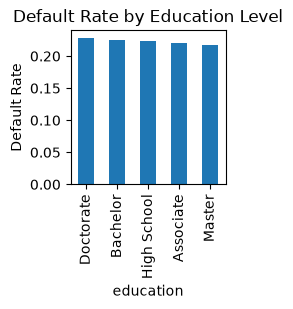

In [ ]:
#Default Education Rate
education_default = (
    df.groupby("education")["loan_status"]
      .mean()
      .sort_values(ascending=False)
)

print(education_default)

#Visualisation
education_default.plot(
    kind='bar',
    figsize=(2,2)
)

plt.title('Default Rate by Education Level')
plt.ylabel('Default Rate')
plt.show()

gender
female    0.222481
male      0.222012
Name: loan_status, dtype: float64


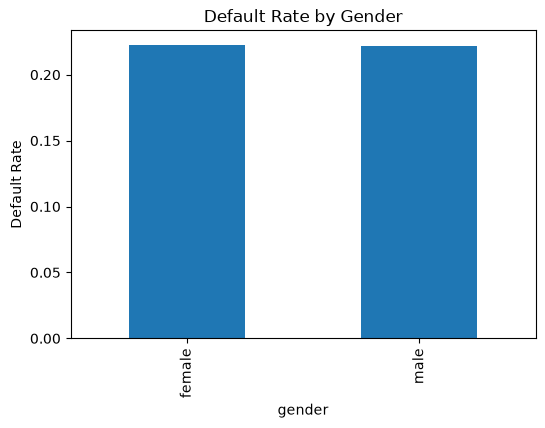

In [7]:
#Default Gender Rate
gender_default = (
    df.groupby('gender')['loan_status']
      .mean()
)

print(gender_default)

#Visualisation
gender_default.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Default Rate by Gender')
plt.ylabel('Default Rate')
plt.show()

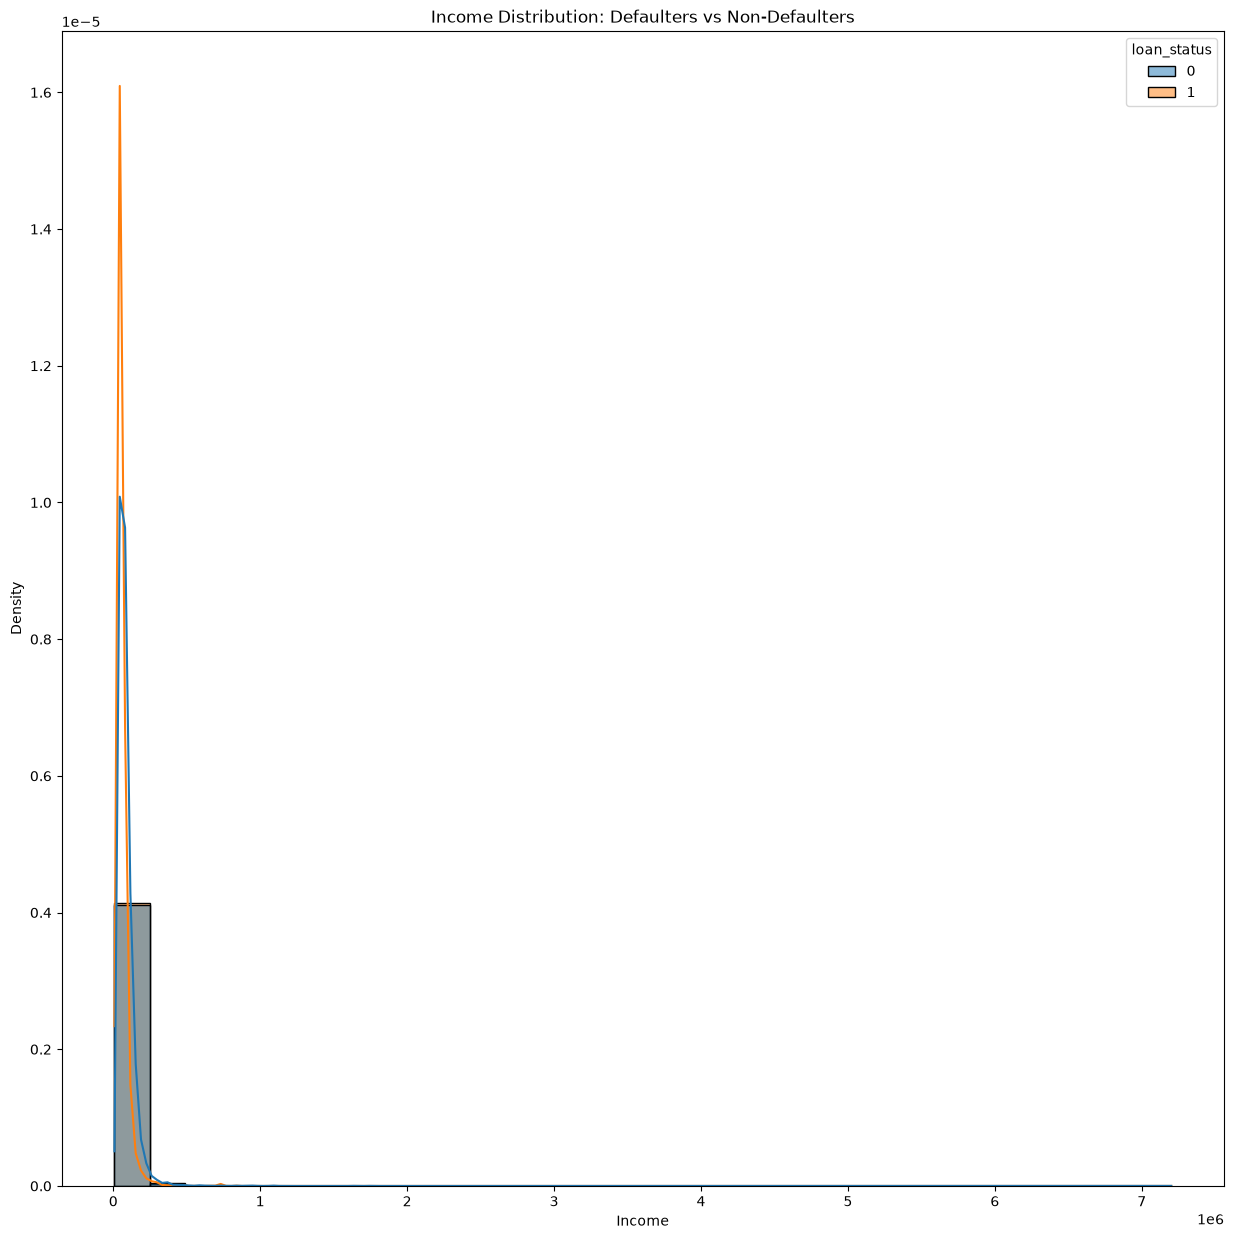

In [14]:
#Income Distribution Comparison for Default and Non-Default people
plt.figure(figsize=(15,15))

sns.histplot(
    data=df,
    x='person_income',
    hue='loan_status',
    bins=30,
    kde=True,
    stat='density',
    common_norm=False
)

plt.title('Income Distribution: Defaulters vs Non-Defaulters')
plt.xlabel('Income')
plt.ylabel('Density')

plt.show()

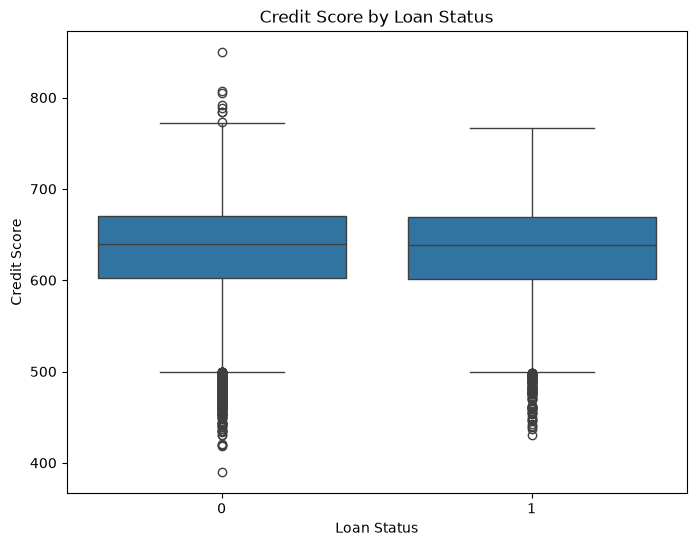

In [15]:
#Credit Score and Loan Status Comparison
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="loan_status",
    y="credit_score"
)

plt.title("Credit Score by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Credit Score")

plt.show()

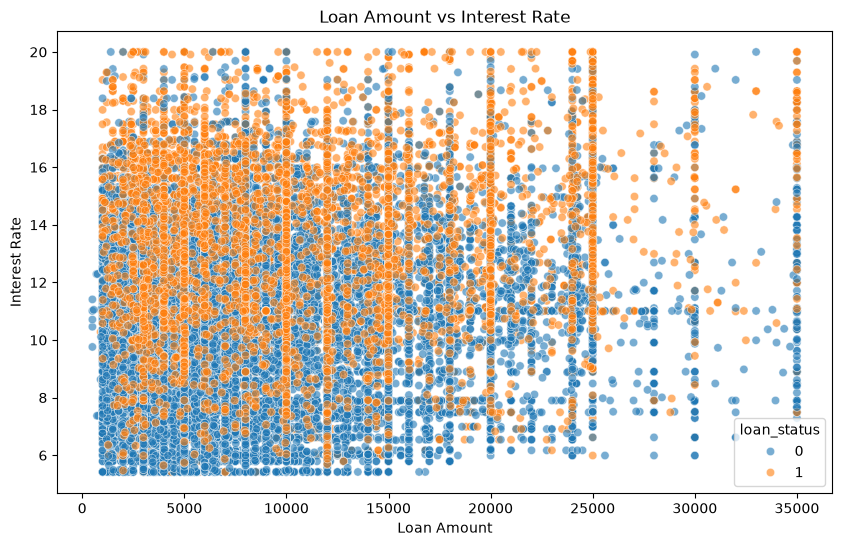

In [16]:
#Loan Amount and Interest Rate Comparison 
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="loan_amount",
    y="loan_interest_rate",
    hue="loan_status",
    alpha=0.6
)

plt.title("Loan Amount vs Interest Rate")
plt.xlabel("Loan Amount")
plt.ylabel("Interest Rate")

plt.show()

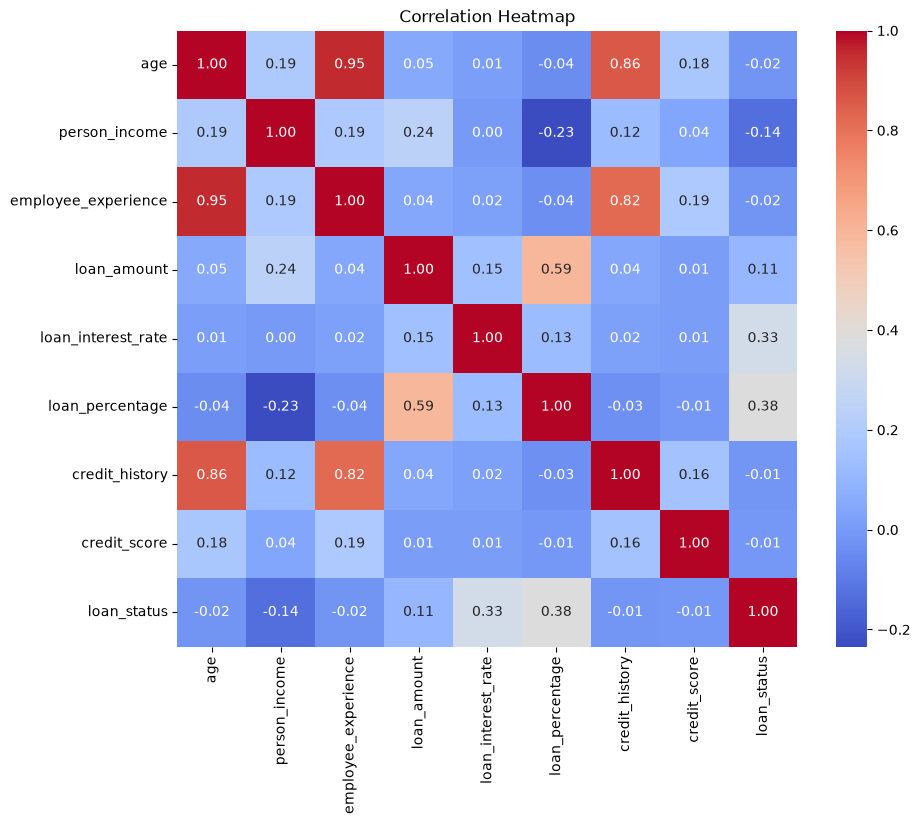

In [17]:
#Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [18]:
#Correlation Analysis
corr_default = (
    df.select_dtypes(include=np.number)
      .corr()["loan_status"]
      .sort_values(key=abs, ascending=False)
)

print(corr_default)

loan_status            1.000000
loan_percentage        0.384880
loan_interest_rate     0.332005
person_income         -0.135808
loan_amount            0.107714
age                   -0.021476
employee_experience   -0.020481
credit_history        -0.014851
credit_score          -0.007647
Name: loan_status, dtype: float64


In [19]:
#Summary
df.groupby("loan_status")[[
    "person_income",
    "credit_score",
    "loan_amount",
    "loan_interest_rate"
]].mean()

,person_income,credit_score,loan_amount,loan_interest_rate
loan_status,,,,
0,86157.040743,632.814914,9219.576914,10.477981
1,59886.096900,631.887200,10855.689800,12.856794
